# 01 — Variational: FISTA + Wavelet (Jacopo)
Self-contained. Auto-finds the shared `.pt` data, uses IPPy's blur operator (same `A` that created the data). `min ½‖Ax−y‖² + λ‖Wx‖₁`.

In [1]:
# --- Setup (run each session) ---
!pip -q install git+https://github.com/devangelista2/IPPy
!pip -q install PyWavelets scikit-image numpy scipy matplotlib pandas

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 110.4 MB/s eta 0:00:0000:010:01


In [ ]:
# ================= PREAMBLE (self-contained) =================
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
import os, glob, torch, numpy as np
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio as _psnr, structural_similarity as _ssim
from IPPy import operators, utilities

# ---- auto-find the shared .pt folder (no need to type the path) ----
hits = glob.glob("/content/drive/MyDrive/**/noise_*.pt", recursive=True)
assert hits, "No noise_*.pt found. Make sure Shivam's retina_processed shortcut is under MyDrive."
PROCESSED = Path(os.path.dirname(os.path.dirname(hits[0])))
print("PROCESSED =", PROCESSED, "| splits:", os.listdir(PROCESSED))

IMG_SIZE = 256
NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

# SAME blur operator that created the degraded data
K = operators.Blurring(img_shape=(IMG_SIZE,IMG_SIZE), kernel_type="motion",
                       kernel_size=9, motion_angle=45)
class IPPyForward:
    @torch.no_grad()
    def A(self, x):  return K(torch.from_numpy(np.ascontiguousarray(x)).float()[None,None])[0,0].detach().numpy()
    @torch.no_grad()
    def AT(self, x): return K.T(torch.from_numpy(np.ascontiguousarray(x)).float()[None,None])[0,0].detach().numpy()
fw = IPPyForward()   # ||K^T K|| ~ 1 => FISTA step L=1 valid

def psnr(g,p): return float(_psnr(g,p,data_range=1.0))
def ssim(g,p): return float(_ssim(g,p,data_range=1.0))# compare ground-truth image (g) and reconstructed image (p)


def noise_file_name(nl): return f"noise_{str(nl).replace('.', '_')}.pt"
def load_pt(split, nl):
    d = torch.load(PROCESSED/split/noise_file_name(nl), map_location="cpu")
    clean    = d["clean"].numpy()[:,0].astype(np.float32)
    degraded = d["degraded"].numpy()[:,0].astype(np.float32)
    return clean, degraded

cl, dg = load_pt("test", 0.01)
print("test set:", cl.shape[0], "images | PSNR(img0):", round(psnr(cl[0],dg[0]),2))
# ============================ END PREAMBLE ============================

Mounted at /content/drive
PROCESSED = /content/drive/MyDrive/GroupF/retina_processed | splits: ['train', 'validation', 'test']
test set: 600 images | PSNR(img0): 34.51


### Method

In [ ]:
import pywt
WAVELET, LEVEL, MODE = "db4", 3, "periodization"#wavelet (Daubechies db4, 3 livelli)
def _W(z): return pywt.coeffs_to_array(pywt.wavedec2(z,WAVELET,mode=MODE,level=LEVEL))#trasforma l'immagine in coeffic. wavelet
def _Winv(a,sl): return pywt.waverec2(pywt.array_to_coeffs(a,sl,output_format="wavedec2"),WAVELET,mode=MODE)#inverso
def _soft(z,t): return np.sign(z)*np.maximum(np.abs(z)-t,0.0)#soft-thresholding: avvicina ogni valore a zero di t e azzera quelli sotto soglia.
def fista_wavelet(y, fw, lam, n_iter=300):
    L=1.0; x=np.clip(fw.AT(y),0,1); z=x.copy(); t=1.0
    for _ in range(n_iter):
        a,sl=_W(z-fw.AT(fw.A(z)-y)/L)
        xn=np.clip(_Winv(_soft(a,lam/L),sl),0,1)
        tn=(1+np.sqrt(1+4*t*t))/2; z=xn+((t-1)/tn)*(xn-x); x,t=xn,tn
    return x

# The core. x starts from Aᵀy. For 300 iterations:
# fw.A(z)-y = how much the re-blurred estimate deviates from the data; fw.AT(...) brings this error back to the image domain (it is the gradient);
# z - gradient/L is the step towards the data.
# _W(...) transforms into wavelet, _soft(a, lam/L) shrinks the coefficients (threshold = λ/L), _Winv recomposes → new estimate xn. np.clip(...,0,1) keeps the values in [0,1].
# tn and z=xn+((t-1)/tn)*(xn-x) are the FISTA momentum (the acceleration).

### Scoring + output path

In [4]:
import pandas as pd
def _scores_pt(fn, split, sigma, lam, n=None):
    clean, degraded = load_pt(split, sigma)
    if n: clean, degraded = clean[:n], degraded[:n]
    ps=[]; ss=[]
    for x, y in zip(clean, degraded):
        r = fn(y, fw, lam)
        ps.append(psnr(x,r)); ss.append(ssim(x,r))
    return np.mean(ps), np.std(ps), np.mean(ss), np.std(ss)

OUT_METRICS = str(PROCESSED.parent / "GroupF_Output" / "metrics")
os.makedirs(OUT_METRICS, exist_ok=True)
print("metrics ->", OUT_METRICS)

metrics -> /content/drive/MyDrive/GroupF/GroupF_Output/metrics


### Heuristic λ + preview

lam=0.001  PSNR 42.21 SSIM 0.967
lam=0.002  PSNR 40.78 SSIM 0.963
lam=0.005  PSNR 38.91 SSIM 0.953
lam=0.01   PSNR 37.60 SSIM 0.943
lam=0.02   PSNR 36.48 SSIM 0.930
best lambda: 0.001


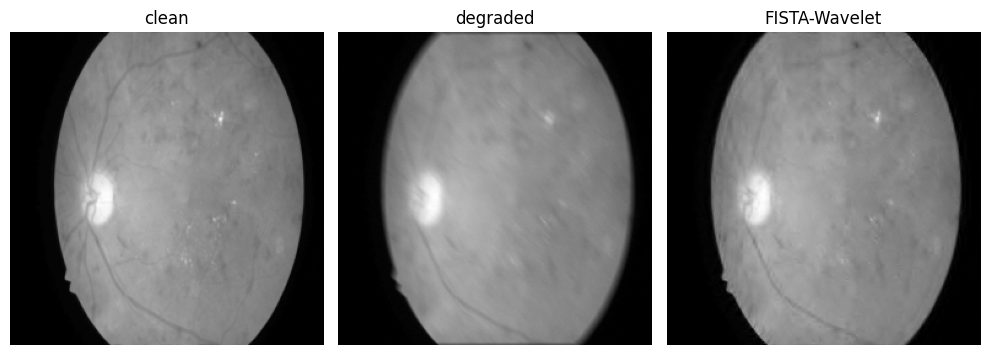

In [ ]:
import matplotlib.pyplot as plt
cl, dg = load_pt("test", 0.01); x, y = cl[0], dg[0]
rows=[]
for lam in [0.001,0.002,0.005,0.01,0.02]:
    r=fista_wavelet(y,fw,lam,200); rows.append((lam,psnr(x,r),ssim(x,r)))
    print(f"lam={lam:<6} PSNR {psnr(x,r):.2f} SSIM {ssim(x,r):.3f}")
best=max(rows,key=lambda t:t[1]); print("best lambda:",best[0])
rec=fista_wavelet(y,fw,best[0],300)
fig,ax=plt.subplots(1,3,figsize=(10,3.6))
for a,im,tt in zip(ax,[x,y,rec],["clean","degraded","FISTA-Wavelet"]):
    a.imshow(im,cmap="gray"); a.set_title(tt); a.axis("off")
plt.tight_layout(); plt.show()

# Quick test on a single image: tries several λ, picks the best one by PSNR, reconstructs and shows clean/degraded/reconstructed side by side.
# It only serves to visually check that it works; it does not produce official results.


# For each noise level, tries every λ on 40 validation images, records which one gives the best PSNR and which the best SSIM,
# and saves everything to fista_tuning.csv.
# chosen selects, for each σ, the λ with the best SSIM (sorted by ssim, and .iloc[-1] takes the last = the highest).

### Tune λ on validation

In [ ]:
LAMBDAS=[0.001,0.002,0.005,0.01,0.02]; N_TUNE=40
tune_rows=[]
for sigma in NOISE_LEVELS:
    bp=(None,-1); bs=(None,-1)
    for lam in LAMBDAS:
        pm,_,sm,_=_scores_pt(fista_wavelet,"validation",sigma,lam,n=N_TUNE)
        tune_rows.append({"sigma":sigma,"lambda":lam,"psnr":pm,"ssim":sm})
        if pm>bp[1]: bp=(lam,pm)
        if sm>bs[1]: bs=(lam,sm)
    print(f"sigma={sigma}: best-PSNR lam={bp[0]} ({bp[1]:.2f}) | best-SSIM lam={bs[0]} ({bs[1]:.3f})")
tune_df=pd.DataFrame(tune_rows); tune_df.to_csv(f"{OUT_METRICS}/fista_tuning.csv",index=False)
chosen={s: float(tune_df[tune_df.sigma==s].sort_values("ssim").iloc[-1]["lambda"]) for s in NOISE_LEVELS}
print("chosen lambdas (SSIM):", chosen)
# For each noise level, tries every λ on 40 validation images, records which one gives the best PSNR and which the best SSIM,
# and saves everything to fista_tuning.csv.
# chosen selects, for each σ, the λ with the best SSIM (sorted by ssim, and .iloc[-1] takes the last = the highest).

sigma=0.005: best-PSNR lam=0.001 (41.29) | best-SSIM lam=0.001 (0.968)
sigma=0.01: best-PSNR lam=0.001 (40.81) | best-SSIM lam=0.001 (0.961)
sigma=0.05: best-PSNR lam=0.005 (35.05) | best-SSIM lam=0.02 (0.890)
sigma=0.1: best-PSNR lam=0.02 (33.28) | best-SSIM lam=0.02 (0.806)
chosen lambdas (SSIM): {0.005: 0.001, 0.01: 0.001, 0.05: 0.02, 0.1: 0.02}


### Full evaluation on test (resume-safe)

In [7]:
final=[]
for sigma in NOISE_LEVELS:
    out=f"{OUT_METRICS}/fista_sigma{sigma}.csv"
    if os.path.exists(out):
        print(f"sigma={sigma} già salvato, salto"); final.append(pd.read_csv(out).iloc[0].to_dict()); continue
    lam=float(chosen[sigma])
    pm,psd,sm,ssd=_scores_pt(fista_wavelet,"test",sigma,lam)
    row={"method":"fista","sigma":sigma,"lambda":lam,"psnr_mean":pm,"psnr_std":psd,"ssim_mean":sm,"ssim_std":ssd}
    final.append(row); pd.DataFrame([row]).to_csv(out,index=False)
    print(f"sigma={sigma}  PSNR {pm:.2f}±{psd:.2f}  SSIM {sm:.3f}±{ssd:.3f}  (lam={lam})")
pd.DataFrame(final).to_csv(f"{OUT_METRICS}/fista_all.csv",index=False); print("saved fista_all.csv")

# Evaluates the method with the chosen λ on all 600 test images, and saves a CSV for that σ.
# At the end it merges everything into fista_all.csv, which is the final result of your FISTA part.

sigma=0.005  PSNR 41.44±2.46  SSIM 0.968±0.013  (lam=0.001)
sigma=0.01  PSNR 40.95±2.57  SSIM 0.961±0.017  (lam=0.001)
sigma=0.05  PSNR 34.53±2.53  SSIM 0.891±0.039  (lam=0.02)
sigma=0.1  PSNR 33.49±2.80  SSIM 0.800±0.091  (lam=0.02)
saved fista_all.csv
